## Missing Values
Missing values occurs in dataset when some of the informations is not stored for a variable
There are 3 mechanisms

### 1 Missing Completely at Random, MCAR:
Missing completely at random (MCAR) is a type of missing data mechanism in which the probability of a value being missing is unrelated to both the observed data and the missing data. In other words, if the data is MCAR, the missing values are randomly distributed throughout the dataset, and there is no systematic reason for why they are missing.

For example, in a survey about the prevalence of a certain disease, the missing data might be MCAR if the survey participants with missing values for certain questions were selected randomly and their missing responses are not related to their disease status or any other variables measured in the survey.


### 2. Missing at Random MAR:
Missing at Random (MAR) is a type of missing data mechanism in which the probability of a value being missing depends only on the observed data, but not on the missing data itself. In other words, if the data is MAR, the missing values are systematically related to the observed data, but not to the missing data.
Here are a few examples of missing at random:

Income data: Suppose you are collecting income data from a group of people, but some participants choose not to report their income. If the decision to report or not report income is related to the participant's age or gender, but not to their income level, then the data is missing at random.

Medical data: Suppose you are collecting medical data on patients, including their blood pressure, but some patients do not report their blood pressure. If the patients who do not report their blood pressure are more likely to be younger or have healthier lifestyles, but the missingness is not related to their actual blood pressure values, then the data is missing at random.

## 3. Missing data not at random (MNAR) 
It is a type of missing data mechanism where the probability of missing values depends on the value of the missing data itself. In other words, if the data is MNAR, the missingness is not random and is dependent on unobserved or unmeasured factors that are associated with the missing values.

For example, suppose you are collecting data on the income and job satisfaction of employees in a company. If employees who are less satisfied with their jobs are more likely to refuse to report their income, then the data is not missing at random. In this case, the missingness is dependent on job satisfaction, which is not directly observed or measured.

In [2]:
import seaborn as sns

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# check missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# Delete the rows or data points to handle missing values
df.shape
#when ever there is missing points drop that data point or droping nan values 
df.dropna().shape #it is not good because we are lossing huge amount of data 

(182, 15)

In [6]:
#column wise delection or delete columns with many Missing values
df.dropna(axis=1) #it will delete all the columns which have nan values 


,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


In [7]:
# Imputation Techniques for Missing Values - can be used to fill in missing values. The main imputation techniques are mean, median, mode, and random sample imputation.

# 1. Mean Value Imputation
# Mean value imputation replaces missing values with the mean of the column. This technique works well when the data is normally distributed.
df['Age_mean'] = df['age'].fillna(df['age'].mean())
# Mean Imputation works well when we have normally distributed data

In [8]:
df[['Age_mean','age']] #we have replace missing value with mean of age in age_mean

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


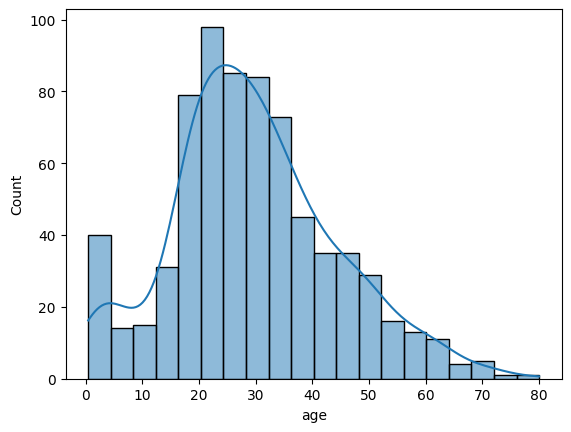

In [9]:
import matplotlib.pyplot as plt
sns.histplot(df['age'],kde=True)
plt.show()

In [10]:
# 2. Median value Imputation - If we have outliers in the dataset
df['Age_median'] = df['age'].fillna(df['age'].median())


In [11]:
df[['Age_median','Age_mean','age']]

,Age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


In [12]:
# 3. Mode Imputation Technqies - This can be used as Categorical Values
# embarked is an example for Missing Completely at Random(MCAR)
df[df['embarked'].isnull()]
df['embarked'].unique()
# Mode
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [13]:
df['embarked_mode']=df['embarked'].fillna(mode_value)

In [14]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [15]:
df['embarked_mode'].isnull().sum() # itr will show zero null values 

np.int64(0)

In [16]:
df['embarked'].isnull().sum() # if we check embarked it will show 2 missing values

np.int64(2)

### Handling Outliers 

#### Five-Number Summary and Box Plot
- Minimum, Maximum, Median, Q1,Q3,IQR

In [17]:
import numpy as np 

In [18]:
lst_marks = [45, 32, 56, 75, 89, 54, 32, 89, 90, 87, 67, 54, 45, 98, 99, 67, 74]
minimum,Q1,median,Q3,maximum = np.quantile(lst_marks,[0,0.25,0.5,0.75,1.0])

In [19]:
minimum,Q1,median,Q3,maximum # 5 number summary 

(np.float64(32.0),
 np.float64(54.0),
 np.float64(67.0),
 np.float64(89.0),
 np.float64(99.0))

In [20]:
IQR = Q3 - Q1
print(IQR)

35.0


In [ ]:
lower_fence = Q1 - 1.5 * (IQR)
upper_fence = Q3 + 1.5 * (IQR)
lower_fence
upper_fence
# Any value lower than lower_fence is Outliers
# Any value greater than upper_fence is Outliers


np.float64(1.5)

In [27]:
lst_marks = [45, 32, 56, 75, 89, 54, 32, 89, 90, 87, 67, 54, 45, 98, 99, 67, 74]

In [28]:
import seaborn as sns

<Axes: >

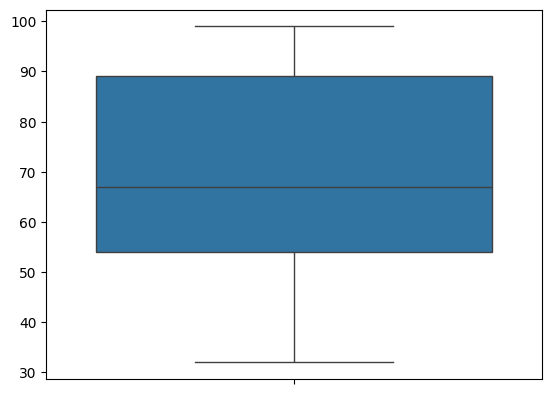

In [30]:
# Boxplot 
sns.boxplot(lst_marks)

<Axes: >

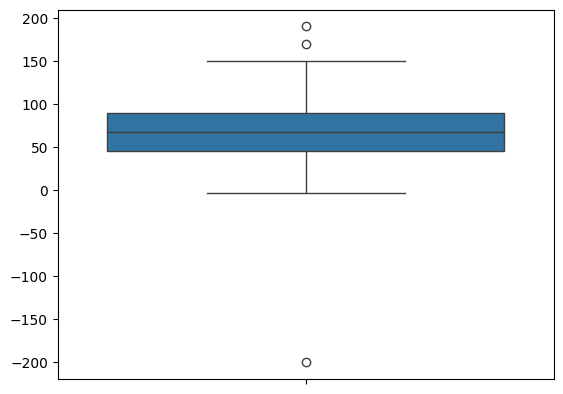

In [33]:
# Adding outliers values 
lst_marks = [-4,-3,-200,45, 32, 56, 75, 89, 54, 32, 89, 90, 87, 67, 54, 45, 98, 99, 67, 74,150,170,190]

sns.boxplot(lst_marks)